In [1]:
import hashlib
import sqlite3
import socket
import threading
from datetime import datetime
from fastapi import FastAPI, Request
from fastapi.responses import RedirectResponse
import uvicorn

# I'm using FastAPI because it's faster to set up for a hackathon
app = FastAPI()

# This set acts as a quick cache to check if we've seen a user today
# It resets every time I restart the script
seen_users_today = set()

def get_network_ip():
    """ 
    I found this trick online to find my laptop's IP address.
    This way, I can open the link on my phone as long as it's on the same Wi-Fi.
    """
    try:
        s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
        s.connect(('8.8.8.8', 80))
        addr = s.getsockname()[0]
        s.close()
        return addr
    except:
        return '127.0.0.1'

def create_db_tables():
    """ 
    Setting up the SQLite database. I'm keeping it simple with one table.
    Added 'is_unique' so I can easily count new vs returning users later.
    """
    conn = sqlite3.connect("smartlink_data.db")
    # I'm using 'IF NOT EXISTS' so it doesn't crash on the second run
    conn.execute('''
        CREATE TABLE IF NOT EXISTS click_history (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            link_name TEXT,
            click_time TEXT,
            device TEXT,
            is_unique INTEGER
        )
    ''')
    conn.close()

@app.get("/r/{link_name}")
async def handle_redirect(link_name: str, request: Request):
    # --- STEP 1: SMART ROUTING LOGIC ---
    # My idea: Redirect to different channels based on the time of day
    now = datetime.now()
    hour = now.hour
    
    # 6 AM to 6 PM is 'Day Mode'
    if 6 <= hour < 18:
        target = "https://youtube.com/@radheshyamdasdevotionalvideos"
    else:
        target = "https://youtube.com/@vedantashala"
    
    # --- STEP 2: DEVICE DETECTION ---
    # Just checking the header string for the word 'mobile'
    user_agent = request.headers.get("user-agent", "").lower()
    if "mobile" in user_agent:
        current_device = "Mobile"
    else:
        current_device = "Desktop"
    
    # --- STEP 3: UNIQUE VISITOR CHECK ---
    # I'm hashing the IP + Date so I don't store raw IP addresses (privacy)
    user_ip = request.client.host
    today = now.strftime('%Y-%m-%d')
    unique_key = hashlib.md5(f"{user_ip}-{today}".encode()).hexdigest()
    
    # Check if we've seen this hash in our set
    if unique_key in seen_users_today:
        new_visitor = 0 # Returning user
    else:
        seen_users_today.add(unique_key)
        new_visitor = 1 # First time today
        
    # --- STEP 4: SAVE TO DATABASE ---
    try:
        db = sqlite3.connect("smartlink_data.db")
        db.execute(
            "INSERT INTO click_history (link_name, click_time, device, is_unique) VALUES (?, ?, ?, ?)",
            (link_name, now.isoformat(), current_device, new_visitor)
        )
        db.commit()
        db.close()
        print(f"Recorded click for {link_name} from {current_device}")
    except Exception as e:
        print(f"DB Error: {e}")
    
    return RedirectResponse(url=target)

def start_app():
    """ Function to boot up the server with the right settings """
    create_db_tables()
    my_ip = get_network_ip()
    
    print(f"--- SERVER STARTING ---")
    print(f"PC Link: http://127.0.0.1:8000/r/test")
    print(f"Phone Link: http://{my_ip}:8000/r/test")
    
    # I had to look up 'nest_asyncio' because Uvicorn is picky in Jupyter
    import nest_asyncio
    nest_asyncio.apply()
    uvicorn.run(app, host="0.0.0.0", port=8000)

# Running in a thread so I can still use the notebook while the server is up
threading.Thread(target=start_app, daemon=True).start()

--- SERVER STARTING ---
PC Link: http://127.0.0.1:8000/r/test
Phone Link: http://10.145.241.104:8000/r/test


INFO:     Started server process [31308]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


Recorded click for test from Desktop
INFO:     127.0.0.1:57204 - "GET /r/test HTTP/1.1" 307 Temporary Redirect
Recorded click for test from Desktop
INFO:     127.0.0.1:63162 - "GET /r/test HTTP/1.1" 307 Temporary Redirect
Recorded click for test from Desktop
INFO:     127.0.0.1:53374 - "GET /r/test HTTP/1.1" 307 Temporary Redirect
Recorded click for test from Mobile
INFO:     10.145.116.140:38210 - "GET /r/test HTTP/1.1" 307 Temporary Redirect
Recorded click for test from Mobile
INFO:     10.145.116.140:42494 - "GET /r/test HTTP/1.1" 307 Temporary Redirect
Recorded click for test from Desktop
INFO:     127.0.0.1:55426 - "GET /r/test HTTP/1.1" 307 Temporary Redirect


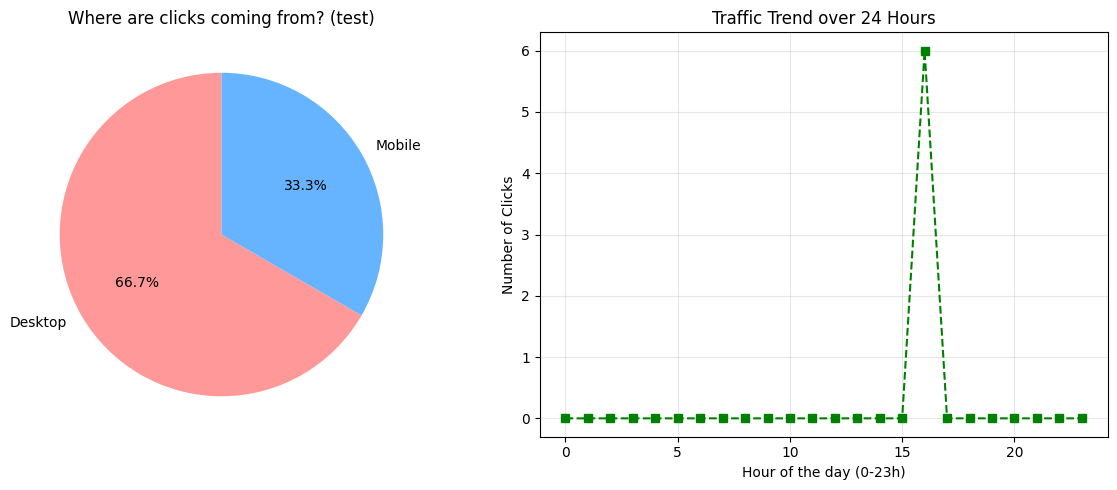


--- QUICK STATS FOR test ---
Total Clicks: 6
Unique Visitors: 2
Note: Desktop traffic is high. The current layout is probably fine.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

def make_my_dashboard(short_code):
    """
    I wrote this function to pull data for a specific link 
    and turn it into a few simple charts for my project report.
    """
    # Step 1: Connect to the database we made in the other script
    db_file = "smartlink_data.db"
    
    try:
        conn = sqlite3.connect(db_file)
        # Using Pandas to read the SQL table directly into a DataFrame
        # I'm filtering by 'link_name' so I only see data for one specific link
        df = pd.read_sql_query("SELECT * FROM click_history WHERE link_name = ?", 
                               conn, params=(short_code,))
        conn.close()
    except Exception as e:
        print(f"Error loading the database: {e}")
        return

    # Just a safety check so the script doesn't crash if the table is empty
    if df.empty:
        print(f"No data yet for '{short_code}'. Go click the link a few times!")
        return

    # --- CHART 1: PIE CHART FOR DEVICES ---
    # Setting up a figure with two side-by-side plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Counting how many times 'Mobile' and 'Desktop' appear
    device_counts = df['device'].value_counts()
    
    # I picked these colors manually to make it look nicer than the default
    ax1.pie(device_counts, labels=device_counts.index, autopct='%1.1f%%', 
            colors=['#ff9999','#66b3ff'], startangle=90)
    ax1.set_title(f"Where are clicks coming from? ({short_code})")

    # --- CHART 2: HOURLY TRAFFIC TREND ---
    # Converting the 'click_time' string into a real Python datetime
    df['click_time'] = pd.to_datetime(df['click_time'])
    # Extracting just the hour (0-23)
    df['hour'] = df['click_time'].dt.hour
    
    # I want to show all 24 hours, even if some have 0 clicks
    # I'm creating a blank series for all 24 hours and filling it in
    hourly_data = df['hour'].value_counts().reindex(range(24), fill_value=0)

    ax2.plot(hourly_data.index, hourly_data.values, color='green', marker='s', linestyle='--')
    ax2.set_xlabel("Hour of the day (0-23h)")
    ax2.set_ylabel("Number of Clicks")
    ax2.set_title("Traffic Trend over 24 Hours")
    ax2.grid(True, alpha=0.3) # Adding a faint grid to make it easier to read

    plt.tight_layout()
    plt.show()

    # --- STEP 3: SIMPLE LOGIC INSIGHTS ---
    total = len(df)
    uniques = df['is_unique'].sum()
    
    print(f"\n--- QUICK STATS FOR {short_code} ---")
    print(f"Total Clicks: {total}")
    print(f"Unique Visitors: {uniques}")

    # My basic logic for a 'recommendation'
    mobile_count = device_counts.get('Mobile', 0)
    if mobile_count > (total * 0.5):
        print("Note: Most people are on phones. I should make the landing page vertical!")
    else:
        print("Note: Desktop traffic is high. The current layout is probably fine.")

# Run it for my test link
make_my_dashboard("test")